Initial Root Node Gini: 0.6550 (n=20)

========== Evaluating feature: x1 ==========
Split <= 2.25  | Left Gini: 0.000 (n=1 ) | Right Gini: 0.643 (n=19) | Weighted Gini: 0.6105
Split <= 2.65  | Left Gini: 0.500 (n=2 ) | Right Gini: 0.648 (n=18) | Weighted Gini: 0.6333
Split <= 2.90  | Left Gini: 0.444 (n=3 ) | Right Gini: 0.630 (n=17) | Weighted Gini: 0.6020
Split <= 3.10  | Left Gini: 0.625 (n=4 ) | Right Gini: 0.633 (n=16) | Weighted Gini: 0.6312
Split <= 3.35  | Left Gini: 0.560 (n=5 ) | Right Gini: 0.604 (n=15) | Weighted Gini: 0.5933
Split <= 3.60  | Left Gini: 0.611 (n=6 ) | Right Gini: 0.602 (n=14) | Weighted Gini: 0.6048
Split <= 3.85  | Left Gini: 0.612 (n=7 ) | Right Gini: 0.592 (n=13) | Weighted Gini: 0.5989
Split <= 4.05  | Left Gini: 0.594 (n=8 ) | Right Gini: 0.542 (n=12) | Weighted Gini: 0.5625
Split <= 4.30  | Left Gini: 0.593 (n=9 ) | Right Gini: 0.512 (n=11) | Weighted Gini: 0.5485
Split <= 4.75  | Left Gini: 0.580 (n=10) | Right Gini: 0.420 (n=10) | Weighted Gini: 0.5

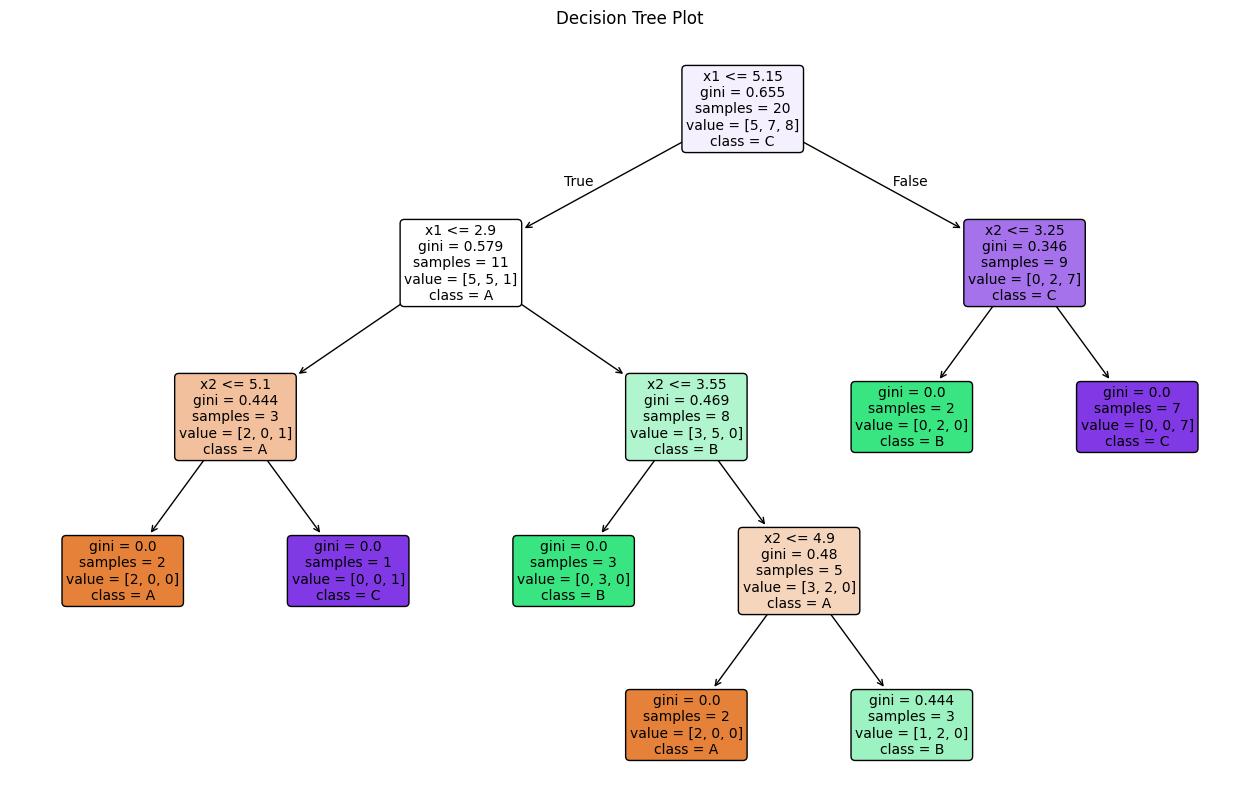

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# 1. Load the Dataset
data = {
    'x1': [2, 3, 4, 5, 6, 2.5, 3.2, 4.1, 5.3, 6.7, 7.1, 2.8, 3.5, 5.6, 6.8, 3.7, 4.5, 5.9, 7.3, 8],
    'x2': [3, 2, 4, 5, 3, 6, 7, 5.2, 4.5, 2.8, 3.5, 4.2, 3.1, 6.3, 5.1, 2.9, 4.8, 5.7, 4.4, 6],
    'y':  ['A', 'B', 'A', 'B', 'B', 'C', 'A', 'B', 'C', 'B', 'C', 'A', 'B', 'C', 'C', 'B', 'A', 'C', 'C', 'C']
}
df = pd.DataFrame(data)

# 2. Custom Function to Calculate Gini Impurity
def gini_impurity(y):
    if len(y) == 0: return 0
    counts = Counter(y)
    probabilities = [count / len(y) for count in counts.values()]
    return 1 - sum(p**2 for p in probabilities)

# 3. Custom Function to Evaluate All Splits (Root Node Example)
def evaluate_all_splits(df, features, target):
    best_gini = float('inf')
    best_split = None

    print(f"Initial Root Node Gini: {gini_impurity(df[target]):.4f} (n={len(df)})\n")

    for feature in features:
        # Get unique, sorted values to find candidate thresholds (midpoints)
        values = sorted(df[feature].unique())
        thresholds = [(values[i] + values[i+1]) / 2 for i in range(len(values)-1)]
        
        print(f"{'='*10} Evaluating feature: {feature} {'='*10}")
        
        for thresh in thresholds:
            # Split the data
            left_mask = df[feature] <= thresh
            right_mask = df[feature] > thresh
            
            y_left = df[left_mask][target]
            y_right = df[right_mask][target]
            
            n_left = len(y_left)
            n_right = len(y_right)
            n_total = n_left + n_right
            
            # Calculate Gini for both sides
            gini_left = gini_impurity(y_left)
            gini_right = gini_impurity(y_right)
            
            # Calculate Weighted Gini
            weighted_gini = (n_left / n_total) * gini_left + (n_right / n_total) * gini_right
            
            print(f"Split <= {thresh:<5.2f} | "
                  f"Left Gini: {gini_left:.3f} (n={n_left:<2}) | "
                  f"Right Gini: {gini_right:.3f} (n={n_right:<2}) | "
                  f"Weighted Gini: {weighted_gini:.4f}")
            
            # Track the best split
            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_split = {'feature': feature, 'threshold': thresh, 'gini': weighted_gini}

    print("\n" + "*"*45)
    print(f"=> BEST ROOT SPLIT: Feature '{best_split['feature']}' <= {best_split['threshold']:.2f}")
    print(f"=> Minimum Weighted Gini: {best_split['gini']:.4f}")
    print("*"*45 + "\n")

# Run the manual evaluation for the root node
evaluate_all_splits(df, features=['x1', 'x2'], target='y')

# 4. Build the Full Tree and Plot it using scikit-learn
X = df[['x1', 'x2']]
y = df['y']

# We limit max_depth slightly so the plot remains readable
clf = DecisionTreeClassifier(criterion='gini', random_state=42, max_depth=4)
clf.fit(X, y)

# Plotting the tree
plt.figure(figsize=(16, 10))
plot_tree(clf, 
          feature_names=['x1', 'x2'], 
          class_names=clf.classes_, 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("Decision Tree Plot")
plt.show()

In [3]:
import pandas as pd
from collections import Counter

# 1. Load the Dataset
data = {
    'x1': [2, 3, 4, 5, 6, 2.5, 3.2, 4.1, 5.3, 6.7, 7.1, 2.8, 3.5, 5.6, 6.8, 3.7, 4.5, 5.9, 7.3, 8],
    'x2': [3, 2, 4, 5, 3, 6, 7, 5.2, 4.5, 2.8, 3.5, 4.2, 3.1, 6.3, 5.1, 2.9, 4.8, 5.7, 4.4, 6],
    'y':  ['A', 'B', 'A', 'B', 'B', 'C', 'A', 'B', 'C', 'B', 'C', 'A', 'B', 'C', 'C', 'B', 'A', 'C', 'C', 'C']
}
df = pd.DataFrame(data)

def gini_impurity(y):
    if len(y) == 0: return 0
    probabilities = [count / len(y) for count in Counter(y).values()]
    return 1 - sum(p**2 for p in probabilities)

# 2. Recursive Function to Build the Tree
def build_tree(current_df, features, target, depth=0, max_depth=2):
    indent = "    " * depth  # Indentation to visually show the tree's depth
    
    print(f"\n{indent}{'='*10} NODE AT DEPTH {depth} {'='*10}")
    print(f"{indent}Current Node Gini: {gini_impurity(current_df[target]):.4f} (Samples: {len(current_df)})")
    
    # --- LEAF NODE PREDICTION LOGIC ---
    counts = Counter(current_df[target])
    majority_class = counts.most_common(1)[0][0] # Get the most frequent class
    
    # Stop if the node is entirely pure
    if len(counts) == 1:
        print(f"{indent}🛑 STOP: Node is pure. PREDICT CLASS: {majority_class}")
        return
        
    # Stop if we hit our depth limit (Majority Voting)
    if depth >= max_depth:
        class_dist = ", ".join([f"{k}: {v}" for k, v in counts.items()])
        print(f"{indent}🛑 STOP: Max depth reached. PREDICT CLASS: {majority_class} (Distribution: {class_dist})")
        return

    best_gini = float('inf')
    best_split = None

    # --- EVALUATE EVERY SPLIT FOR THIS SPECIFIC NODE ---
    for feature in features:
        values = sorted(current_df[feature].unique())
        thresholds = [(values[i] + values[i+1]) / 2 for i in range(len(values)-1)]
        
        for thresh in thresholds:
            left_mask = current_df[feature] <= thresh
            right_mask = current_df[feature] > thresh
            
            y_left, y_right = current_df[left_mask][target], current_df[right_mask][target]
            n_left, n_right = len(y_left), len(y_right)
            n_total = n_left + n_right
            
            # Skip invalid splits
            if n_left == 0 or n_right == 0: continue
            
            # Calculate Weighted Gini
            weighted_gini = (n_left/n_total)*gini_impurity(y_left) + (n_right/n_total)*gini_impurity(y_right)
            
            # Print the calculation for transparency
            print(f"{indent}Test Split: {feature} <= {thresh:<5.2f} | Weighted Gini: {weighted_gini:.4f}")
            
            # Track the winner
            if weighted_gini < best_gini:
                best_gini = weighted_gini
                best_split = {
                    'feature': feature, 
                    'thresh': thresh, 
                    'left_df': current_df[left_mask], 
                    'right_df': current_df[right_mask]
                }
    
    # If no valid split was found, it becomes a leaf
    if best_split is None:
        return

    # --- RECURSIVE PARTITIONING ---
    print(f"{indent}✅ BEST SPLIT CHOSEN: {best_split['feature']} <= {best_split['thresh']:.2f}")
    
    print(f"\n{indent}--> Branching LEFT (where {best_split['feature']} <= {best_split['thresh']:.2f}):")
    build_tree(best_split['left_df'], features, target, depth + 1, max_depth)
    
    print(f"\n{indent}--> Branching RIGHT (where {best_split['feature']} > {best_split['thresh']:.2f}):")
    build_tree(best_split['right_df'], features, target, depth + 1, max_depth)

# 3. Execute the Tree Builder
# I've set max_depth=2 so the terminal output remains readable.
build_tree(df, features=['x1', 'x2'], target='y', max_depth=4)



========== NODE AT DEPTH 0 ==========
Current Node Gini: 0.6550 (Samples: 20)
Test Split: x1 <= 2.25  | Weighted Gini: 0.6105
Test Split: x1 <= 2.65  | Weighted Gini: 0.6333
Test Split: x1 <= 2.90  | Weighted Gini: 0.6020
Test Split: x1 <= 3.10  | Weighted Gini: 0.6312
Test Split: x1 <= 3.35  | Weighted Gini: 0.5933
Test Split: x1 <= 3.60  | Weighted Gini: 0.6048
Test Split: x1 <= 3.85  | Weighted Gini: 0.5989
Test Split: x1 <= 4.05  | Weighted Gini: 0.5625
Test Split: x1 <= 4.30  | Weighted Gini: 0.5485
Test Split: x1 <= 4.75  | Weighted Gini: 0.5000
Test Split: x1 <= 5.15  | Weighted Gini: 0.4737
Test Split: x1 <= 5.45  | Weighted Gini: 0.5250
Test Split: x1 <= 5.75  | Weighted Gini: 0.5659
Test Split: x1 <= 5.95  | Weighted Gini: 0.5976
Test Split: x1 <= 6.35  | Weighted Gini: 0.5733
Test Split: x1 <= 6.75  | Weighted Gini: 0.5188
Test Split: x1 <= 6.95  | Weighted Gini: 0.5588
Test Split: x1 <= 7.20  | Weighted Gini: 0.5944
Test Split: x1 <= 7.65  | Weighted Gini: 0.6263
Test Spli